<a href="https://colab.research.google.com/github/GermanAlmanza14/Econometria_con_Python/blob/main/Quadratic_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### License: Creative Commons Attribution 4.0 International (CC BY 4.0)
This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).
<br>
© 2025 Germán Almanza ralmanza@uacj.mx


# **Forma funcional cuadrática**

Ahora introduciremos la **forma funcional cuadrática**, esta es una variante de la regresión lineal multiple, consiste en explicar $y$ asumiendo solo una variable independiente $x$ en su forma lineal y cuadrática; es decir, consideramos la ecuación
#$$y=\beta_0+\beta_1 x+\beta_2 x^2+u.$$

El modelo de regresión cuadrática nos permite interpretar relaciones no-lineales, como rendimientos marginales variables y en algunos casos identificar el punto crítico (punto máximo o mínimo) de la curva. Esta carácteristica es escencial para comprentender una amplia gamma de fenomenos que se capturan en los datos.

###**1. Forma de la curva**
* El coeficiente $\beta_2$ define la curvatura

    * si $\beta_2>0$ la curva es convexa, forma$-\bigcup$;
    * si  $\beta_2< 0$ la curva es concava, forma$-\bigcap$.
###**2. Pendiente de la curva**
Observa que la pendiente de la curva esta definida por
$$\frac{dy}{dx}=\beta_1+2\beta_2x,\qquad(\spadesuit)$$
esta ecuación describe una relación lineal de $y$ con respecto a $x$. De modo que cuando $x$ incrementa, la relación $x\sim y$ tiene
      
   * **rendimientos marginales crecientes**  si $\beta_1+2\beta_2x>0$; es decir $\tfrac{dy}{dx}>0$.

   * **rendimientos marginales decrecientes**  si $\beta_1+2\beta_2x<0$; es decir $\tfrac{dy}{dx}<0$.



### **3. Punto crítico**

De cálculo diferencial tenemos que los puntos críticos estan definidos como los ceros de la derivada, por lo tanto, de la ecuación de regresión tenemos
$$\frac{dy}{dx}=\beta_1+2\beta_2x\quad⟹ x_0=-\frac{\beta_1}{2\beta_2},\qquad(\clubsuit)$$

por lo anterior $x_0$ es un punto máximo si $\beta_2<0$ y punto mínimo si $\beta_2>0$.

  # **Regresión cuadrática con datos de `caschool.csv`**

Cuando analizamos los datos de **California Standardized Testing and Reporting**  del [California Department of Education](https://www.cde.ca.gov)., señalamos que la regresión **Log-Log** captura los rendimientos marginales decrecientes de las variables $$testscr\sim avginc.$$
Ahora vamos a probar esto con la regresión cuadrática, recordemos que  los datos de `caschool.csv` contiene información sobre el desempeño en las pruebas, las características de las escuelas y los antecedentes demográficos de los estudiantes. Los datos utilizados aquí provienen de los 420 distritos de K-6 y K-8 de California con datos disponibles para 1999.

* *testscr* son el promedio de las calificaciones de lectura y matemáticas en la Prueba de Logros Stanford 9, una prueba estandarizada administrada a los estudiantes de quinto grado.

* *avginc* es el ingreso per cápita anual promedio en el distrito escolar, medido en miles de dólares de 1998.


In [ ]:
#       1.
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#       2.
import pandas as pd

path="/content/drive/MyDrive/Colab Notebooks/DataSets/caschool.csv"
CA9899=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSets/caschool.csv")
CA9899

,observation_number,dist_cod,county,district,gr_span,enrl_tot,teachers,calw_pct,meal_pct,computer,testscr,comp_stu,expn_stu,str,avginc,el_pct,read_scr,math_scr
0,1,75119,Alameda,Sunol Glen Unified,KK-08,195,10.900000,0.510200,2.040800,67,690.799988,0.343590,6384.911133,17.889910,22.690001,0.000000,691.599976,690.000000
1,2,61499,Butte,Manzanita Elementary,KK-08,240,11.150000,15.416700,47.916698,101,661.200012,0.420833,5099.380859,21.524664,9.824000,4.583333,660.500000,661.900024
2,3,61549,Butte,Thermalito Union Elementary,KK-08,1550,82.900002,55.032299,76.322601,169,643.599976,0.109032,5501.954590,18.697226,8.978000,30.000002,636.299988,650.900024
3,4,61457,Butte,Golden Feather Union Elementary,KK-08,243,14.000000,36.475399,77.049202,85,647.700012,0.349794,7101.831055,17.357143,8.978000,0.000000,651.900024,643.500000
4,5,61523,Butte,Palermo Union Elementary,KK-08,1335,71.500000,33.108601,78.427002,171,640.849976,0.128090,5235.987793,18.671329,9.080333,13.857677,641.799988,639.900024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,416,68957,San Mateo,Las Lomitas Elementary,KK-08,984,59.730000,0.101600,3.556900,195,704.300049,0.198171,7290.338867,16.474134,28.716999,5.995935,700.900024,707.700012
416,417,69518,Santa Clara,Los Altos Elementary,KK-08,3724,208.479996,1.074100,1.503800,721,706.750000,0.193609,5741.462891,17.862625,41.734108,4.726101,704.000000,709.500000
417,418,72611,Ventura,Somis Union Elementary,KK-08,441,20.150000,3.563500,37.193802,45,645.000000,0.102041,4402.831543,21.885857,23.733000,24.263039,648.299988,641.700012
418,419,72744,Yuba,Plumas Elementary,KK-08,101,5.000000,11.881200,59.405899,14,672.200012,0.138614,4776.336426,20.200001,9.952000,2.970297,667.900024,676.500000


#**1. Regresión lineal**

##$$y=\beta_0+\beta_1 x+u.$$

In [ ]:
import statsmodels. formula.api as stf
import pandas as pd
import numpy as np

## estimacion modelo lineal:
reg_lineal=stf.ols('testscr~avginc', data=CA9899).fit()
reg_lineal.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                testscr   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     430.8
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           2.75e-66
Time:                        17:29:43   Log-Likelihood:                -1684.5
No. Observations:                 420   AIC:                             3373.
Df Residuals:                     418   BIC:                             3381.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    625.3836      1.532    408.106      0.000     622.371     628.396
avginc         1.8785      0.091     20.756      0.000       1.701       2.056
==============================================================================
Omnibus:                        2.473   Durbin-Watson:                   0.650
Prob(Omnibus):                  0.290   Jarque-Bera (JB):                2.480
Skew:                          -0.148   Prob(JB):                        0.289
Kurtosis:                       2.766   Cond. No.                         39.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## **Definición de tabla de resultados (regresión lineal)**



In [ ]:
# Tabla Regresión lineal:
Table01=pd.DataFrame({'beta': round(reg_lineal.params, 2),
                      'sigma': round(reg_lineal.bse, 4),
                      't-val': round(reg_lineal.tvalues, 4),
                      'p-val': round(reg_lineal.pvalues, 4)})
#     Presenta la tabla y el R-squared
print(f'Tabla lin-lin: \n{Table01}\n')
print(f'R^2={round(reg_lineal.rsquared, 4)}\n')
#print(f'Adj_R^2={round(reg_lineal.rsquared_adj, 4)}\n')

# Definir variable-estimadores
Betas=Table01['beta'].reset_index(drop=True)
B0=Betas[0]
B1=Betas[1]
Rsqrt=round(reg_lineal.rsquared, 4)

Tabla lin-lin: 
             beta   sigma     t-val  p-val
Intercept  625.38  1.5324  408.1060    0.0
avginc       1.88  0.0905   20.7565    0.0

R^2=0.5076



In [ ]:
def Estimacion_prom(m):
  return 1.8785*m+625.3836

Eprm0=Estimacion_prom(0)
Eprm50=Estimacion_prom(50)


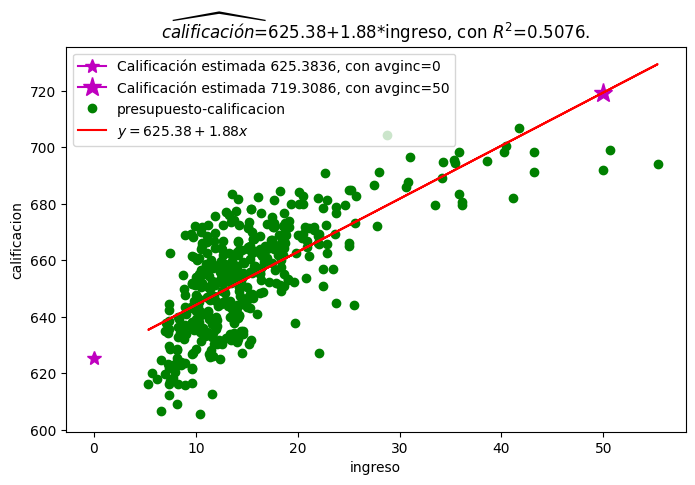

In [ ]:
import matplotlib.pyplot as plt

#hours~lwage
plt.figure(figsize=(8,5))

plt.plot(0,Eprm0,color='m',marker='*', markersize=10,label=f'Calificación estimada {Eprm0}, con avginc=0')
plt.plot(50,Eprm50,color='m',marker='*', markersize=14,label=f'Calificación estimada {Eprm50}, con avginc=50')
plt.plot('avginc','testscr',data=CA9899,color='g',marker='o',linestyle='',label='presupuesto-calificacion')
plt.plot(CA9899['avginc'],reg_lineal.fittedvalues,color='red',linestyle='-',label=f'$y={B0}+{B1}x$')

plt.ylabel ('calificacion')
plt.xlabel ('ingreso')
#   titulo
plt.title(r'$\widehat{calificación}$'f'={B0}+{B1}*ingreso, con ' r'$R^2$='f'{Rsqrt}.', size=12)
plt.legend()
plt.savefig('Lineal_CI.jpg')
plt.show()

In [ ]:
max_testscr=max(CA9899['testscr'])
min_testscr=min(CA9899['testscr'])

print(f'Promedio máximo {max_testscr}')
print(f'Promedio mínimo {min_testscr:.2f}')


Promedio máximo 706.75
Promedio mínimo 605.55


#**2. Regresión lineal con forma funcional cuadrática**

##$$y=\beta_0+\beta_1 x+\beta_2 x^2+u.$$


### **La función ```I()```**

Esta función esta dentro de las fórmulas de la biblioteca `patsy`, que ```statsmodels``` utiliza para analizar las fórmulas y crear la matriz de diseño para la regresión.
* La función `I(var)` (de "Identidad") dentro de la fórmula le indica a `patsy` que trate la expresión dentro de `I(var)` como una expresión literal de Python y la evalúe directamente, en lugar de interpretar sus componentes según la sintaxis de la fórmula de `patsy`.

* Esto es crucial para incluir términos como x**2 o np.log(x) directamente como predictores en el modelo OLS, ya que, de lo contrario, `patsy` interpretaría ** de forma diferente o no reconocería np.log().

En esencia, todavía estás realizando MCO, pero en un conjunto de variables independientes transformadas, lo que hace que el modelo sea lineal en sus parámetros aun cuando la relación entre la variable independiente original y la variable dependiente no sea lineal.

El modelo que vamos a realizar es el siguiente
$$\widehat{testscr}=\beta_0+\beta_1 avginc+\beta_2 I(avginc^2).$$


In [ ]:
## estimacion modelo cuadratico:
reg_quad=stf.ols('testscr~avginc+I(avginc**2)', data=CA9899).fit()
reg_quad.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                testscr   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     261.3
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           2.78e-74
Time:                        17:47:11   Log-Likelihood:                -1662.7
No. Observations:                 420   AIC:                             3331.
Df Residuals:                     417   BIC:                             3344.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        607.3017      3.046    199.362      0.000     601.314     613.290
avginc             3.8510      0.304     12.657      0.000       3.253       4.449
I(avginc ** 2)    -0.0423      0.006     -6.758      0.000      -0.055      -0.030
==============================================================================
Omnibus:                        0.556   Durbin-Watson:                   0.951
Prob(Omnibus):                  0.757   Jarque-Bera (JB):                0.378
Skew:                          -0.048   Prob(JB):                        0.828
Kurtosis:                       3.111   Cond. No.                     2.23e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.23e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Tabla Regresión lineal:
Table01=pd.DataFrame({'beta': round(reg_lineal.params, 4),
                      'sigma': round(reg_lineal.bse, 4),
                      't-val': round(reg_lineal.tvalues, 4),
                      'p-val': round(reg_lineal.pvalues, 4)})
#     Presenta la tabla y el R-squared
print(f'Tabla Regresión lineal: \n{Table01}\n')
print(f'R^2={round(reg_lineal.rsquared, 4)}\n')
#print(f'Adj_R^2={round(reg_lineal.rsquared_adj, 4)}\n')

# Definir variable-estimadores
Betas=Table01['beta'].reset_index(drop=True)
B0=Betas[0]
B1=Betas[1]
Rsqrt=round(reg_lineal.rsquared, 4)

#                   Quadratic Regression
# Tabla Regresión Quadratic:
Table02=pd.DataFrame({'beta': round(reg_quad.params, 4),
                      'sigma': round(reg_quad.bse, 4),
                      't-val': round(reg_quad.tvalues, 4),
                      'p-val': round(reg_quad.pvalues, 4)})
#     Presenta la tabla y el R-squared de la Quadratic
print(f'Tabla Regresión Cuadrática: \n{Table02}\n')
print(f'R^2={round(reg_quad.rsquared, 4)}\n')
#print(f'Adj_R^2={round(reg_lineal.rsquared_adj, 4)}\n')

# Definir variable-estimadores
QBetas=Table02['beta'].reset_index(drop=True)
QB0=QBetas[0]
QB1=QBetas[1]
QB2=QBetas[2]

QRsqrt=round(reg_quad.rsquared, 4)

Tabla Regresión lineal: 
               beta   sigma     t-val  p-val
Intercept  625.3836  1.5324  408.1060    0.0
avginc       1.8785  0.0905   20.7565    0.0

R^2=0.5076

Tabla Regresión Cuadrática: 
                    beta   sigma     t-val  p-val
Intercept       607.3017  3.0462  199.3624    0.0
avginc            3.8510  0.3043   12.6569    0.0
I(avginc ** 2)   -0.0423  0.0063   -6.7585    0.0

R^2=0.5562



# **Interpretación:**

La regresión anterior define la siguiente ecuación

$$\widehat{testscr}=607.3017+3.8510*avginc-0.0423*avginc^2$$


In [ ]:
min(CA9899['testscr'])

605.550048828125

In [ ]:
#x=20
3.8510/(2*0.0423)

45.520094562647756

#**3. Interpretación de la regresión cuadrática**


Dado que los estimadores tienen un $p-value<0.01$, podemos afirmar que éstos son estadisticamente significativos a un 99%. Por otra parte, $R^2=0.5562$ señala que la regresión cuadrática explica poco más del 55% de las observaciones.

##**3.1 El impacto del *avginc* sobre *testscr***
Si solo nos interesa analizar el impacto de la variable independiente, basta poner atención a la ecuación $(\spadesuit)$, en nuestro caso, la ecuación tiene la forma
$$\frac{\widehat{testscr}}{d \;avginc}=3.8510-2\times0.0423\;avginc,\qquad(2\spadesuit)$$
en este caso $\beta_1=3.8510$ se interpreta como la razón de cambio de $avginc=0$ a $avginc=1$; es decir, si el presupuesto promedio en la zona escolar pasa de 0 a 1mil dolares, se estima un incremento en el promedio de calificación de 3.85 pts. En este caso, el coeficiente del término cuadrático no se utilizo y quizá esta interpretación no tenga un significado **económico** relevante, ya que en la muestra, ninguna de las escuelas tiene un presupuesto de 1mil dolares. De hecho, el presupuesto mínimo es de $\$5,335.00$ dlls.

Por otra parte, si el presupuesto pasa

* de $10$ mil a $11$ mil dlls, el promedio de calificación incrementa en
$$3.8510-2\times0.0423(10)=3.0\;pts.,$$

* de $20$ mil a $21$ mil dlls, el promedio de calificación incrementa en
$$3.8510-2\times0.0423(20)=2.15\;pts.,$$

* de $30$ mil a $31$ mil dlls, el promedio de calificación incrementa en
$$3.8510-2\times0.0423(30)=1.3\;pts.,$$


* de $40$ mil a $41$ mil dlls, el promedio de calificación incrementa en
$$3.8510-2\times0.0423(40)=0.46\;pts.$$

Las estimaciones anteriores dan muestra de que el incremento del presupuesto escolar tiene **rendimientos marginales decrecientes**.

##**3.2 Presupuesto promedio óptimo (*avginc*)**

La ecuación $(\clubsuit)$ identifica el vértice de la parábola, esto lo interpretamos como el **presupuesto óptimo**
$$avginc^*=-\frac{3.8510}{-2\times0.0423}=45.52.$$

Sin embargo, esta estimación no es del todo confiable ya que, en la siguiente gráfica se puede observar que en esta observación hay escuelas que con menor presupuesto *$avginc^*<45.52$* alcanzan una mayor puntuación $testscr^*<695$.

* **Observación:** Quizá el estimador del presupuesto óptimo este sesgado por omición de otras variables de control como: determinantes geográficos, número de matricula escolar, número de profesores, etc.

##**3.3 Regresión cuadrática**

Lo que podemos señalar de la regresión cuadrática es que se ajusta muy bien a las observaciones; es decir, describe una buena estimación de las observaciones y describe los rendimientos marginales decrecientes del presupuesto escolar sobre el nivel promedio de calificaciones.

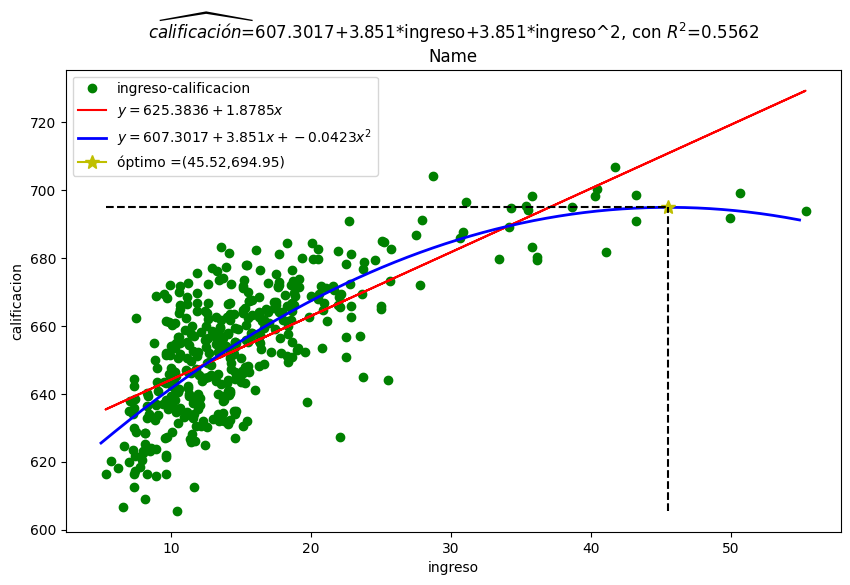

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

x=np.arange(5,55, 0.1)
y=QB0+QB1*x+QB2*x**2
x0=-QB1/(2*QB2)
y0=QB0+QB1*x0+QB2*x0**2
xinf=min(CA9899['avginc'])
yinf=min(CA9899['testscr'])


plt.plot('avginc','testscr',data=CA9899,color='g',marker='o',linestyle='',label='ingreso-calificacion')
plt.plot(CA9899['avginc'],reg_lineal.fittedvalues,color='red',linestyle='-',label=f'$y={B0}+{B1}x$')
plt.plot(x, y, color='b',label=f'$y={QB0}+{QB1}x+{QB2}x^2$',linewidth=2)
plt.plot(x0,y0,color='y',marker='*',linestyle='-',label=f'óptimo =({x0:.2f},{y0:.2f})',  markersize=10)

#  dashed line
plt.plot([x0,x0],[yinf,y0],color='k',linestyle='dashed')
plt.plot([xinf,x0],[y0,y0],color='k',linestyle='dashed')

plt.ylabel ('calificacion')
plt.xlabel ('ingreso')
#   titulo
plt.title(r'$\widehat{calificación}$'f'={QB0}+{QB1}*ingreso+{QB1}*ingreso^2, con ' r'$R^2$='f'{QRsqrt}\n'
'Name', size=12)
plt.legend()
plt.savefig('Lineal_CI.jpg')
plt.show()